# clustering analysis: customer segmentation

**5*a by ahmed abobakr**

## project overview
this project focuses on segmenting customers based on their behavior and demographics. using clustering algorithms, we aim to identify distinct groups of customers to enable targeted marketing strategies.

## objectives
1.  **data preparation**: load and clean the customer dataset.
2.  **preprocessing**: encode categorical variables and scale features.
3.  **optimal k**: determine the best number of clusters using the elbow method.
4.  **modeling**: apply k-means clustering to segment customers.
5.  **evaluation**: analyze the clusters and visualize the results.

---

## 1. import libraries
importing necessary libraries for data analysis, visualization, and clustering.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("libraries imported successfully")

libraries imported successfully


---

## 2. load dataset
loading the customer segmentation data.

In [9]:
df = pd.read_csv('clustering_customers.csv')
print(f"dataset shape: {df.shape}")
df.head()

dataset shape: (5000, 7)


,CustomerID,Age,Annual_Income,Spending_Score,Gender,Work_Experience,Family_Size
0,1,56,143000,47,Male,0,5
1,2,69,87000,76,Female,29,5
2,3,46,60000,69,Male,36,1
3,4,32,120000,31,Female,22,1
4,5,60,46000,92,Male,0,3


### simulating real-world data issues
since the original dataset is clean, we will introduce some missing values and duplicates to demonstrate the preprocessing capabilities required for this project.

In [10]:
# introduce missing values
np.random.seed(42)
mask = np.random.random(df.shape) < 0.05  # 5% missing data
df_dirty = df.mask(mask)

# introduce duplicates
duplicates = df_dirty.sample(n=100, random_state=42)
df = pd.concat([df_dirty, duplicates], ignore_index=True)

print(f"dataset shape after adding issues: {df.shape}")
print(f"missing values count: {df.isnull().sum().sum()}")
print(f"duplicates count: {df.duplicated().sum()}")

dataset shape after adding issues: (5100, 7)
missing values count: 1754
duplicates count: 100


---

## 3. data preprocessing
cleaning the data by removing nulls and duplicates, encoding gender, and scaling numerical features.

In [11]:
# 1. clean data
df = df.dropna()
df = df.drop_duplicates()
print(f"shape after cleaning: {df.shape}")

# 2. encode gender
le = LabelEncoder()
if 'Gender' in df.columns:
    df['Gender'] = le.fit_transform(df['Gender'])

# 3. select features and scale
features = ['Age', 'Annual_Income', 'Spending_Score', 'Work_Experience', 'Family_Size']
features = [col for col in features if col in df.columns]
X = df[features]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("data preprocessing completed")

shape after cleaning: (3518, 7)
data preprocessing completed


---

## 4. determine optimal clusters
using the elbow method to find the optimal number of clusters (k).

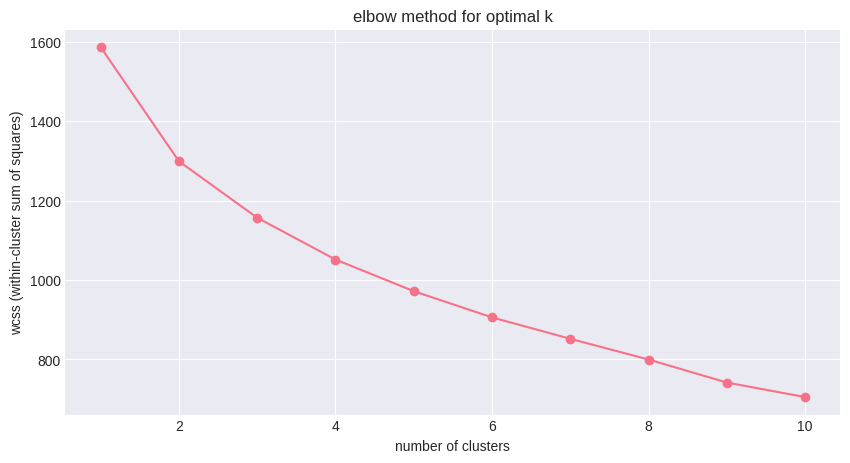

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('elbow method for optimal k')
plt.xlabel('number of clusters')
plt.ylabel('wcss (within-cluster sum of squares)')
plt.show()

---

## 5. model building: k-means clustering
applying k-means with the chosen number of clusters (k=4).

In [13]:
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

print(f"k-means clustering completed with k={k}")

k-means clustering completed with k=4


---

## 6. evaluation & visualization
evaluating the model using silhouette score and visualizing the customer segments.

silhouette score: 0.1489


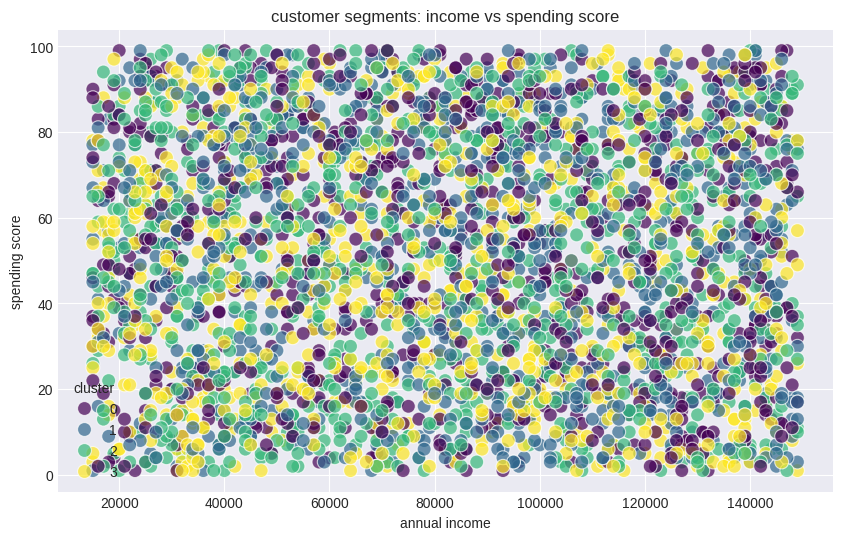

In [14]:
score = silhouette_score(X_scaled, clusters)
print(f"silhouette score: {score:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('customer segments: income vs spending score')
plt.xlabel('annual income')
plt.ylabel('spending score')
plt.legend(title='cluster')
plt.show()

## conclusion

**5*a by ahmed abobakr**

we have successfully segmented the customers into distinct groups based on their income and spending habits. this information can be valuable for targeted marketing campaigns.